In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Data Loading
data = pd.read_csv('Superstore sales dataset.csv')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
data.shape

(9994, 21)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
data.duplicated().sum()
# no duplicates to drop

0

In [7]:
data.isna().sum()
# no nulls to be filled

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
data[['Sales','Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [9]:
#Category Analysis
category_summary = data.groupby('Category')[['Sales','Profit']].sum().round(2).sort_values('Profit',ascending=False)
category_summary

,Sales,Profit
Category,,
Technology,836154.03,145454.95
Office Supplies,719047.03,122490.80
Furniture,741999.80,18451.27


# Insight:
Technology generated the highest profit  145k USD

Furniture generated relatively high sales 742k USD but only 18k USD profit ,

suggesting potential profitability issues in this category.

In [10]:
#Sub-Category Analysis
subcategory_summary = data.groupby('Sub-Category')[['Sales','Profit']].sum().round(2).sort_values('Profit',ascending=False)
subcategory_summary

,Sales,Profit
Sub-Category,,
Copiers,149528.03,55617.82
Phones,330007.05,44515.73
Accessories,167380.32,41936.64
Paper,78479.21,34053.57
Binders,203412.73,30221.76
Chairs,328449.10,26590.17
Storage,223843.61,21278.83
Appliances,107532.16,18138.01
Furnishings,91705.16,13059.14


# Sub-Category Analysis

Tables and Bookcases are the only major sub-categories generating losses.

Tables generated approximately 207K USD in sales but resulted in a loss of about 17.7K USD.

This indicates that high sales volume does not necessarily translate into profitability.

In [11]:
#Discount Analysis
discount_summary =data.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)
discount_summary

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64

In [12]:
tables = data[data['Sub-Category'] == 'Tables']
tables[['Sales','Discount','Profit']].describe()

,Sales,Discount,Profit
count,319.000000,319.000000,319.000000
mean,648.794771,0.261285,-55.565771
std,615.774655,0.169622,230.565006
min,24.368000,0.000000,-1862.312400
25%,244.006000,0.200000,-122.829300
50%,447.840000,0.300000,-31.372200
75%,872.170000,0.400000,33.851700
max,4297.644000,0.500000,629.010000


# Table Products Analysis

Tables are the largest loss-generating sub-category.

Despite generating over 206K USD in sales, table products produced a total loss of approximately $17.7K.

The average profit per order is negative (-55.6), while the median profit is also negative (-31.4), indicating that losses are widespread rather than being caused by a few extreme transactions.

Tables also receive relatively high discounts, with an average discount of 26.1%.

In [13]:
data[['Sales', 'Discount', 'Profit']].corr()

,Sales,Discount,Profit
Sales,1.000000,-0.028190,0.479064
Discount,-0.028190,1.000000,-0.219487
Profit,0.479064,-0.219487,1.000000


There is a moderate negative relationship between discount levels and profitability.

In [14]:
#Regional Analysis
region_summary = data.groupby('Region')[['Sales', 'Profit']].sum().round(2).sort_values('Profit',ascending = False)
region_summary

,Sales,Profit
Region,,
West,725457.82,108418.45
East,678781.24,91522.78
South,391721.91,46749.43
Central,501239.89,39706.36


In [15]:
#Product Analysis
product_summary = data.groupby('Product Name')[['Sales', 'Profit']].sum().round(2).sort_values('Profit',ascending = False)
product_summary.head(10)

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
Canon PC1060 Personal Laser Copier,11619.83,4570.93
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98
Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.29,3696.28
Ibico EPK-21 Electric Binding System,15875.92,3345.28


In [58]:
product_summary.tail(15)

,Sales,Profit
Product Name,,
Bretford “Just In Time” Height-Adjustable Multi-Task Work Tables,5634.90,-964.19
O'Sullivan 4-Shelf Bookcase in Odessa Pine,2740.20,-975.10
Hon 2090 “Pillow Soft” Series Mid Back Swivel/Tilt Chairs,5282.42,-989.05
Epson TM-T88V Direct Thermal Printer - Monochrome - Desktop,1212.70,-1057.23
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",4446.18,-1147.40
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,1706.25,-1148.44
Balt Solid Wood Round Tables,6518.75,-1201.06
Martin Yale Chadless Opener Electric Letter Opener,16656.20,-1299.18
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08


# Product Analysis

The most profitable products are primarily technology-related products such as copiers and printers.

Several of the least profitable products belong to the Tables and Bookcases sub-categories, reinforcing previous findings that furniture products contribute disproportionately to overall losses.

In [19]:
data['Order Date']=pd.to_datetime(data['Order Date'])
data['Year Month'] = data['Order Date'].dt.to_period('M')

In [25]:
#Time Series Analysis
monthly_sales = (data.groupby('Year Month')['Sales'].sum().round(2).reset_index())
monthly_sales

,Year Month,Sales
0,2014-01,28953.71
1,2014-02,12743.11
2,2014-03,54801.91
3,2014-04,24710.02
4,2014-05,29639.83
5,2014-06,29287.03
6,2014-07,35341.25
7,2014-08,37854.55
8,2014-09,66110.22
9,2014-10,34561.95


In [29]:
monthly_profit = data.groupby('Year Month')['Profit'].sum().round(2).reset_index()
monthly_profit

,Year Month,Profit
0,2014-01,4549.45
1,2014-02,2654.56
2,2014-03,92.70
3,2014-04,4601.07
4,2014-05,3912.25
5,2014-06,4499.74
6,2014-07,-1783.54
7,2014-08,2081.27
8,2014-09,10232.26
9,2014-10,4075.15


In [38]:
monthly_sales['Year Month'] = monthly_sales['Year Month'].astype(str)
monthly_profit['Year Month'] = monthly_profit['Year Month'].astype(str)

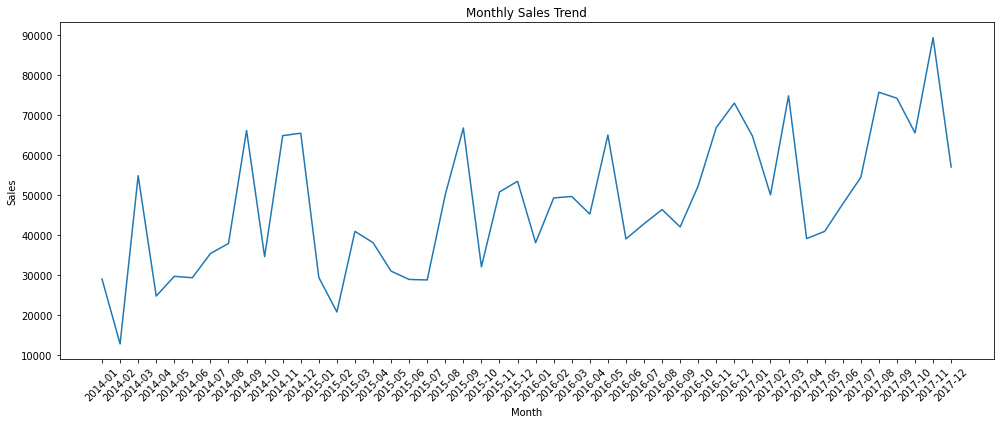

In [43]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_sales,
    x='Year Month',
    y='Sales'
)

plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

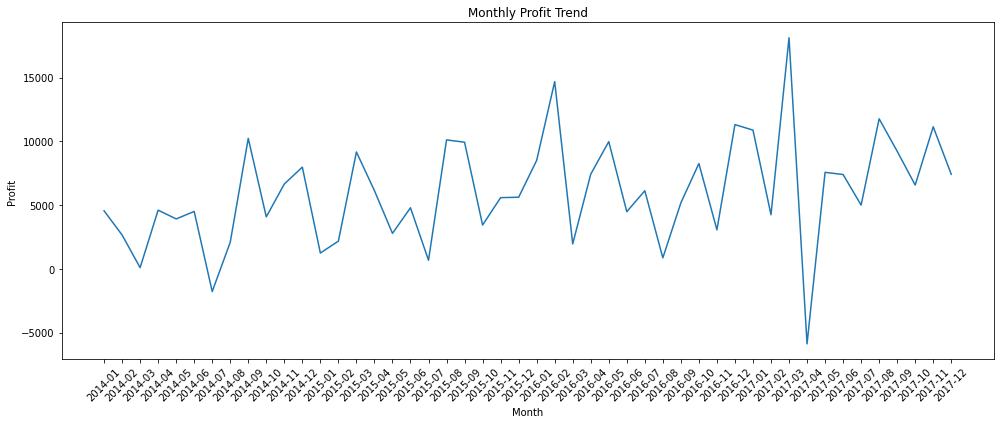

In [44]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_profit,
    x='Year Month',
    y='Profit'
)

plt.xticks(rotation=45)
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')

plt.tight_layout()
plt.show()

# Time Series Analysis
Sales show a clear seasonal pattern, with repeated peaks and dips across different months, indicating that demand is not stable throughout the year.

Higher sales do not always lead to higher profit, suggesting that some high-revenue periods may be associated with increased costs, discounts, or lower-margin products

In [45]:
data['Profit Margin'] = data['Profit'] / data['Sales']

In [53]:
#Profit Margin Analysis
data.groupby('Category')['Profit Margin'].mean().sort_values( ascending = False)

Category
Technology         0.156138
Office Supplies    0.138030
Furniture          0.038784
Name: Profit Margin, dtype: float64

In [57]:
data.groupby('Sub-Category')['Profit Margin'].mean().sort_values( ascending = False)

Sub-Category
Labels         0.429663
Paper          0.425600
Envelopes      0.423140
Copiers        0.317194
Fasteners      0.299171
Art            0.251646
Accessories    0.218210
Furnishings    0.137066
Phones         0.119222
Supplies       0.112039
Storage        0.089113
Chairs         0.043900
Machines      -0.072026
Bookcases     -0.126640
Tables        -0.147727
Appliances    -0.156869
Binders       -0.199595
Name: Profit Margin, dtype: float64

Initial profit margin calculations were based on the average of row-level profit margins.

However, this approach may be misleading because each transaction receives equal weight regardless of sales volume.

Therefore, profit margin was recalculated using aggregated sales and profit values at the sub-category level.

In [64]:
subcategory_margin = data.groupby('Sub-Category')[['Sales','Profit']].sum()
subcategory_margin['Profit Margin'] = subcategory_margin['Profit'] / subcategory_margin['Sales']
subcategory_margin.sort_values( 'Profit Margin').sort_values('Profit Margin' , ascending = False)

,Sales,Profit,Profit Margin
Sub-Category,,,
Labels,12486.3120,5546.2540,0.444187
Paper,78479.2060,34053.5693,0.433918
Envelopes,16476.4020,6964.1767,0.422676
Copiers,149528.0300,55617.8249,0.371956
Fasteners,3024.2800,949.5182,0.313965
Accessories,167380.3180,41936.6357,0.250547
Art,27118.7920,6527.7870,0.240711
Appliances,107532.1610,18138.0054,0.168675
Binders,203412.7330,30221.7633,0.148574


# Profit Margin Analysis

Tables, Bookcases, and Supplies are the only sub-categories with negative profit margins.

Tables performed the worst, with a profit margin of -8.6%, indicating that the company loses approximately 8.6 USD for every $100 of table sales.